In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import transforms
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


In [ ]:
def Retrieve_Preprocessed_EuroSAT(Data_Path: str, Use_Pretrained_Model:  bool
                               ):



  os.makedirs(Data_Path, exist_ok=True)

  if Use_Pretrained_Model == True:

    transform = transforms.Compose([transforms.Resize((224,224)),
                                    transforms.RandomHorizontalFlip(0.5),
                                    transforms.RandomVerticalFlip(0.5),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                                                         std = [0.229, 0.224, 0.225])])

  # Will use ResNet for Transfer Learning and the mean and std are the optimal value for it
  # ResNet trained on 224x224 hence Resize

  else:
    transform = transforms.Compose([transforms.RandomHorizontalFlip(0.5),
                                    transforms.RandomVerticalFlip(0.5),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean = [0.3444, 0.3803, 0.4078],
                                                         std = [0.2037, 0.1366, 0.1143]),])

  # For making own model, mean and std values are optimal for Satellite Data

  # Random flips are to give model more variety in training and is done every batch

  # ToTensor makes it between 0.0 and 1.0 which allows for Normalization

  processed_dataset = torchvision.datasets.EuroSAT(root= Data_Path, download=True,
                                           transform=transform)


  return processed_dataset,processed_dataset.class_to_idx


In [ ]:
def Dataset_info(Dataset):
  Num_data = len(Dataset) # Number of Rows
  Factor_testing = np.zeros(shape = (10,))
  for i in range(10):
    Factor_testing[i] = len(Dataset[i])

  a,c,b = np.unique(Factor_testing,return_index=True,return_counts = True)
  Num_factorPerData = int(a[np.argmax(b)]) # Number of Columns


  print("Number of Data:",Num_data)
  print("Dataset storage type:", type(Dataset[23]))
  print("Number of Columns including Label Column:", Num_factorPerData)

  for i in range(Num_factorPerData):
    if hasattr(type(Dataset[c[np.argmax(b)]][i]), "shape"):
      print("Column",i, "has Data Type:", type(Dataset[c[np.argmax(b)]][i]),
            'And Shape: ', Dataset[c[np.argmax(b)]][i].shape )
    else: print("Column",i, "has Data Type:", type(Dataset[c[np.argmax(b)]][i]))

  print('')
  print("Label_Meanings:",Dataset.class_to_idx)




In [ ]:
ESdataset,ESclasses = Retrieve_Preprocessed_EuroSAT( './eurosat_local_data', False )

Dataset_info(ESdataset)

Number of Data: 27000
Dataset storage type: <class 'tuple'>
Number of Columns including Label Column: 2
Column 0 has Data Type: <class 'torch.Tensor'> And Shape:  torch.Size([3, 64, 64])
Column 1 has Data Type: <class 'int'>

Label_Meanings: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:

def Visual_Display(Dataset,Number_Images,Images_per_row,Use_Pretrained_model,Label_index=-1,Image_index=0):


  Multiplyer = len(Dataset)//Number_Images
  #Value to make data shown more diverse / Spread out evenly (for structured dataset)

  Data = [Dataset[i*Multiplyer][Image_index] for i in range(Number_Images)]
  Label = [Dataset[i*Multiplyer][Label_index] for i in range(Number_Images)]
  Data = [img.permute(1,2,0) for img in Data]
  #Change from [C,H,W] to [H,W,C] for matplotlib

  if Use_Pretrained_model == False:
    mean = torch.tensor([0.3444, 0.3803, 0.4078])
    std = torch.tensor([0.2037, 0.1366, 0.1143])

  else:
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

  Data = [(img*std)+mean for img in Data]
   #Unnormalize to make visuals look normal

  plt.figure(figsize=(20,20))
  number_row = ((Number_Images//Images_per_row)+1)

  for i in range(Number_Images):
    plt.subplot(number_row,Images_per_row,i+1 )
    plt.xticks([])
    plt.yticks([])
    plt.imshow(Data[i])
    plt.xlabel(Label[i])

  plt.show



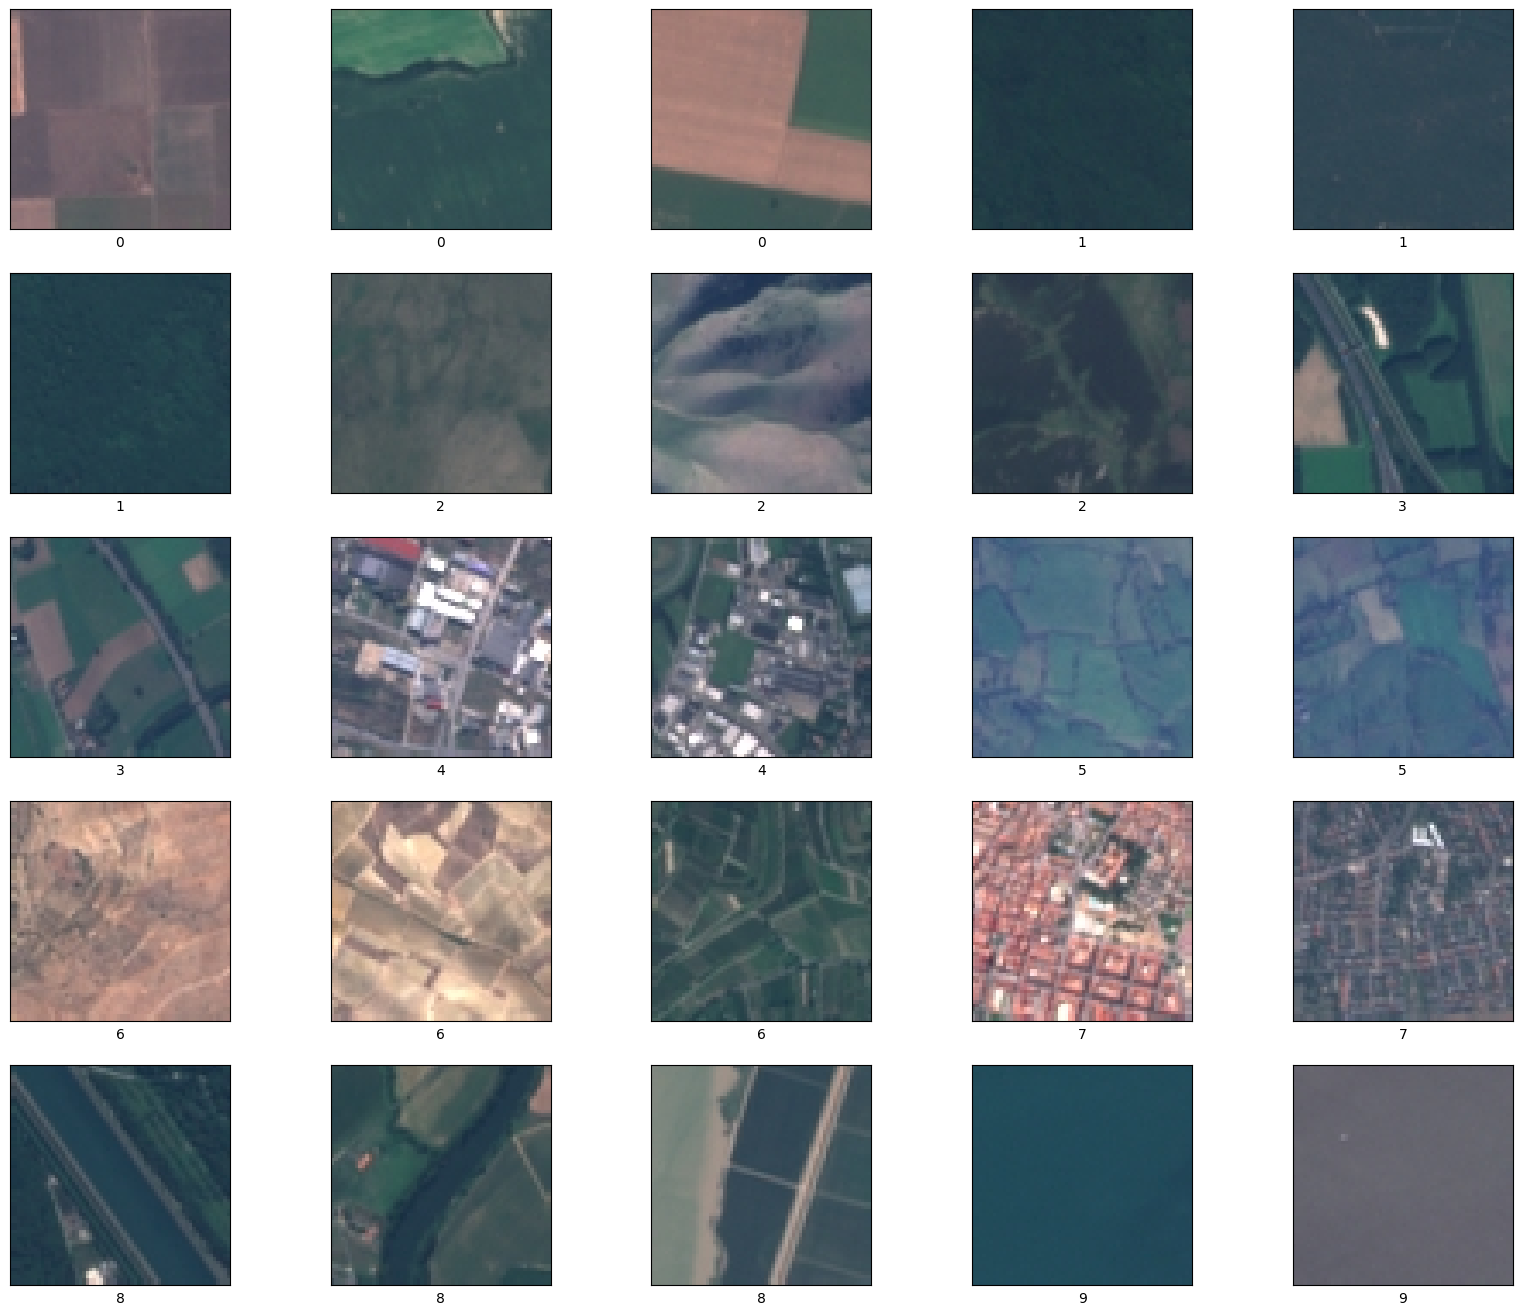

In [ ]:
Visual_Display(ESdataset,25,5,False)

In [ ]:
def Get_Split_data(Dataset,Train_percentage,Validation_percentage,Testing_percentage,seed = 103423423):
  generator = torch.Generator().manual_seed(seed)
  Training_set, Validation_set, Testing_set = random_split(Dataset, [Train_percentage,Validation_percentage, Testing_percentage], generator = generator,)
  return Training_set, Validation_set, Testing_set



In [ ]:

def LoadingData(Train_set, Valid_set, Test_set, Batch_Size = 64):
  Train = DataLoader(Train_set,Batch_Size,shuffle = True)
  Valid = DataLoader(Valid_set,Batch_Size,shuffle = False)
  Test = DataLoader(Test_set,Batch_Size,shuffle = False)

  Num_batches = (len(Train_set)//Batch_Size)+1 if type(len(Train_set)/Batch_Size) == float else len(Train_set)/Batch_Size

  return Train, Valid, Test, Num_batches


In [ ]:
#Building Model
class EuroSAT_CNN(nn.Module):

  def __init__(self,conv_layers:int,conv1_outchannel,dense_layers):
    super().__init__()

    convolutionlayers = []
    denselayers = []
    In_channels = 3
    outchannel = conv1_outchannel//2 #else it will return float


    for i in range(conv_layers):

      convolutionlayers.append(nn.Conv2d(in_channels= In_channels,out_channels= (2*outchannel),
                           kernel_size=3,stride=1,padding=1))
      convolutionlayers.append(nn.ReLU())
      convolutionlayers.append(nn.MaxPool2d(kernel_size=2,stride=2))
      convolutionlayers.append(nn.Dropout(0.25))

      In_channels = 2*outchannel
      outchannel *= (2 if outchannel < 256 else 1)

    dense_input = int(64*64*(conv1_outchannel/2)/(2**conv_layers))
    dense_node = 256*2

    for i in range(dense_layers):

      denselayers.append(nn.Linear(in_features=dense_input,out_features=dense_node//2))
      denselayers.append(nn.ReLU())
      denselayers.append(nn.Dropout(0.5))
      dense_input = dense_node//2
      dense_node //= 2

    denselayers.append(nn.Linear(in_features=dense_input,out_features=10))




    self.convolution = nn.Sequential(*convolutionlayers)
    self.flatten = nn.Flatten()
    self.mlp = nn.Sequential(*denselayers)

  def forward(self,X):
    X = self.convolution(X)
    X = self.flatten(X)
    X = self.mlp(X)

    return X



In [ ]:
def train_model(model,trainloader,lossfunction,optimizer,device):

  model.train() # .train() comes from nn.Module, activates Dropout layers


  accumulateloss = 0
  total_correct_prediction = 0

  for (inputs,labels) in trainloader:

    inputs,labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() #resets gradient values to 0, so previous batch don't affect

    outputs = model(inputs) #auto runs the forward function

    loss = lossfunction(outputs,labels) #Does softmax in CrossEntropy

    loss.backward()

    optimizer.step()

    _,predicted = torch.max(outputs,dim=1)
    correct_predictions = (predicted==labels).sum().item()
    total_correct_prediction += correct_predictions

    accumulateloss += loss.item()*len(inputs)

  Train_loss = (accumulateloss/len(Train_set))
  Train_acc = (total_correct_prediction/len(Train_set))*100


  return Train_acc, Train_loss




In [ ]:
def eval_model(model,ValidLoader,device,lossfunction):
  model.eval() #dropouts disabled

  with torch.no_grad():
    accumulateloss=0
    total_correct_prediction = 0
    for (inputs,labels) in ValidLoader:
      inputs,labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = lossfunction(outputs,labels)

      _,predicted = torch.max(outputs,dim=1)
      correct_predictions = (predicted==labels).sum().item()
      total_correct_prediction += correct_predictions

      accumulateloss += loss.item()*len(inputs)

    Valid_loss = (accumulateloss/len(Valid_set))
    Valid_acc = (total_correct_prediction/len(Valid_set))*100

  return Valid_acc, Valid_loss

In [ ]:
def GCL(model,ModelName,TrainLoader,ValidLoader,optimizer,scheduler,lossfunction,device,Epoches):

  csv_file = f"/content/drive/MyDrive/Colab Notebooks/Projects/EuroSAT/{ModelName}/{ModelName}_history.csv"

  with open(csv_file,"w") as f:
    f.write("Epoche,TrainingAcc,TrainingLoss,ValidAcc,ValidLoss\n")
  Composite_fitness_score = 0

  for i in range(Epoches):
    TrainAcc,TrainLoss = train_model(model,TrainLoader,lossfunction,optimizer,device)
    ValidAcc,ValidLoss = eval_model(model,ValidLoader,device,lossfunction)

    if  (ValidAcc > 90) and (ValidLoss < 0.25):
      if (ValidAcc - (ValidLoss*100)) > Composite_fitness_score:

        Composite_fitness_score = ValidAcc -(ValidLoss*100)
        with open(csv_file,"a") as f:
          f.write(f"{i+1},{TrainAcc},{TrainLoss},{ValidAcc},{ValidLoss}\n")

        save_pathway = f"/content/drive/MyDrive/Colab Notebooks/Projects/EuroSAT/{ModelName}/{ModelName}_Epoche{i+1:03d}.pth"
        torch.save(model.state_dict(),save_pathway)

    print(f"Epoche[{i+1:03d}] || Training Acc: {TrainAcc:.4f} || Training Loss {TrainLoss:.4f} || Validation Acc: {ValidAcc:.4f} || Validation Loss: {ValidLoss:.4f}")
    scheduler.step()



In [ ]:
Train_set, Valid_set, Test_set = Get_Split_data(ESdataset, 0.8,0.1,0.1)
print(len(Train_set), len(Valid_set), len(Test_set))


TrainLoader, ValidLoader, TestLoader, Num_batches = LoadingData(Train_set, Valid_set,Test_set)
print(Num_batches)


21600 2700 2700
338


In [ ]:
model = EuroSAT_CNN(conv_layers=3, conv1_outchannel=16,dense_layers=2).to(DEVICE)
print(DEVICE)

#Compile Model:

lossfunction = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=30,gamma=0.5)

#GCL(model,"Model_CL3_C1Out16_DL2",TrainLoader,ValidLoader,optimizer,scheduler,lossfunction,DEVICE,50)




cpu


In [ ]:
def Model_examination(model,TestLoader,device):

  return


_IncompleteInputError: incomplete input (4141166523.py, line 1)